In [4]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config

In [5]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.power_spectra.Pm_computer import Pm_computer

In [6]:
cfg = Config()

mass_func = MassFuncSheth1999()
bias = BiasTinker2010(cfg)

smooth_profile = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))
smooth_profile_wstellar = smooth_profile + ProfilePointMass()

clump_profile = ProfileNFW(ConcentrationPieri2009_clumps(ConcentrationNeto2007(cfg), d_vir=0.3), 
                            R_virSO(cfg))
clump_profile_wstellar = clump_profile + ProfilePointMass()

clump_distribution = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))
clump_mass_func = ClumpMassGiocoli2010()

TypeError: unsupported operand type(s) for +: 'ProfileNFW' and 'ProfilePointMass'

In [ ]:
Pm_std = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

Pm_stellar = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile_wstellar, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile_wstellar, 
                 clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_comps = Pm_computer(Pm_std, k_vals)
Pm_stellar_comps = Pm_computer(Pm_stellar, k_vals)

interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...


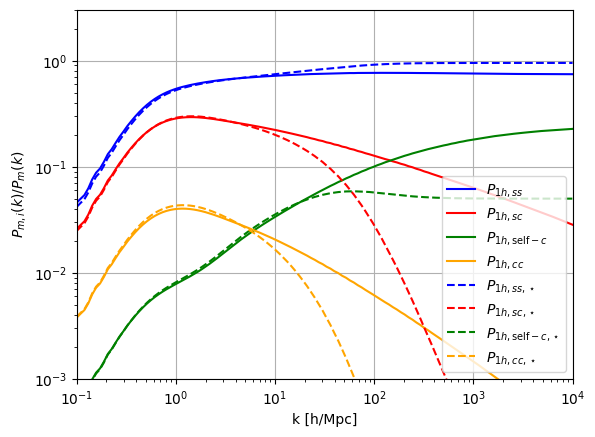

In [ ]:
plt.plot(k_vals, Pm_comps['P_1h_ss']/Pm_comps['P_tot'], label = r'$P_{1h,ss}$', linestyle='-', color='blue')
plt.plot(k_vals, Pm_comps['P_1h_sc']/Pm_comps['P_tot'], label = r'$P_{1h,sc}$', linestyle='-', color='red')
plt.plot(k_vals, Pm_comps['P_1h_self_c']/Pm_comps['P_tot'], label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-', color='green')
plt.plot(k_vals, Pm_comps['P_1h_cc']/Pm_comps['P_tot'], label = r'$P_{1h,cc}$', linestyle='-', color='orange')

plt.plot(k_vals, Pm_stellar_comps['P_1h_ss']/Pm_stellar_comps['P_tot'], label = r'$P_{1h,ss,\star}$', linestyle='--', color='blue')
plt.plot(k_vals, Pm_stellar_comps['P_1h_sc']/Pm_stellar_comps['P_tot'], label = r'$P_{1h,sc,\star}$', linestyle='--',  color='red')
plt.plot(k_vals, Pm_stellar_comps['P_1h_self_c']/Pm_stellar_comps['P_tot'], label = r'$P_{1h,\mathrm{self-}c, \star}$', linestyle='--', color='green')
plt.plot(k_vals, Pm_stellar_comps['P_1h_cc']/Pm_stellar_comps['P_tot'], label = r'$P_{1h,cc, \star}$', linestyle='--', color='orange')


plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-3, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()


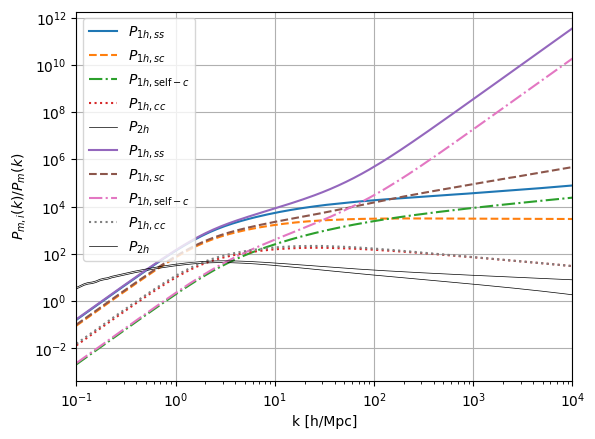

In [ ]:
plt.plot(k_vals, k_vals**3 *Pm_comps['P_1h_ss'], label = r'$P_{1h,ss}$', linestyle='-')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_sc'], label = r'$P_{1h,sc}$', linestyle='--')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_self_c'], label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
plt.plot(k_vals, k_vals**3* Pm_comps['P_1h_cc'], label = r'$P_{1h,cc}$', linestyle=':')
plt.plot(k_vals, k_vals**3* Pm_comps['P_2h'], label=r'$P_{2h}$', color='black', linewidth = 0.5)

plt.plot(k_vals, k_vals**3 *Pm_stellar_comps['P_1h_ss'], label = r'$P_{1h,ss}$', linestyle='-')
plt.plot(k_vals, k_vals**3* Pm_stellar_comps['P_1h_sc'], label = r'$P_{1h,sc}$', linestyle='--')
plt.plot(k_vals, k_vals**3* Pm_stellar_comps['P_1h_self_c'], label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-.')
plt.plot(k_vals, k_vals**3* Pm_stellar_comps['P_1h_cc'], label = r'$P_{1h,cc}$', linestyle=':')
plt.plot(k_vals, k_vals**3* Pm_stellar_comps['P_2h'], label=r'$P_{2h}$', color='black', linewidth = 0.5)


plt.yscale('log')
plt.xscale('log')

plt.ylim(None, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()


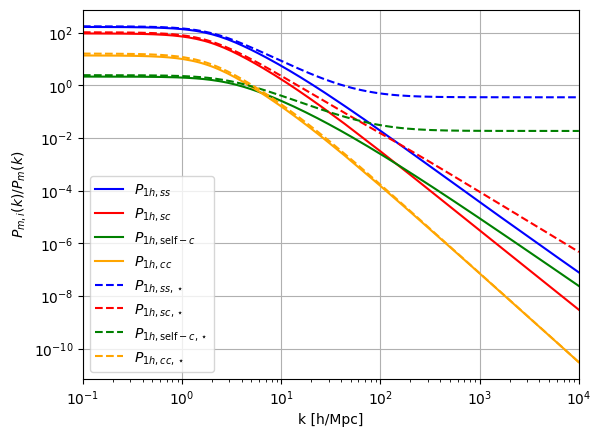

In [ ]:
plt.plot(k_vals, Pm_comps['P_1h_ss'], label = r'$P_{1h,ss}$', linestyle='-', color='blue')
plt.plot(k_vals, Pm_comps['P_1h_sc'], label = r'$P_{1h,sc}$', linestyle='-', color='red')
plt.plot(k_vals, Pm_comps['P_1h_self_c'], label = r'$P_{1h,\mathrm{self-}c}$', linestyle='-', color='green')
plt.plot(k_vals, Pm_comps['P_1h_cc'], label = r'$P_{1h,cc}$', linestyle='-', color='orange')

plt.plot(k_vals, Pm_stellar_comps['P_1h_ss'], label = r'$P_{1h,ss,\star}$', linestyle='--', color='blue')
plt.plot(k_vals, Pm_stellar_comps['P_1h_sc'], label = r'$P_{1h,sc,\star}$', linestyle='--',  color='red')
plt.plot(k_vals, Pm_stellar_comps['P_1h_self_c'], label = r'$P_{1h,\mathrm{self-}c, \star}$', linestyle='--', color='green')
plt.plot(k_vals, Pm_stellar_comps['P_1h_cc'], label = r'$P_{1h,cc, \star}$', linestyle='--', color='orange')


plt.yscale('log')
plt.xscale('log')

plt.ylim(None, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, i}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()